The first few rows is: 
   #                   Name Type 1  Type 2  Total  HP  Attack  Defense  \
0  1              Bulbasaur  Grass  Poison    318  45      49       49   
1  2                Ivysaur  Grass  Poison    405  60      62       63   
2  3               Venusaur  Grass  Poison    525  80      82       83   
3  3  VenusaurMega Venusaur  Grass  Poison    625  80     100      123   
4  4             Charmander   Fire     NaN    309  39      52       43   

   Sp. Atk  Sp. Def  Speed  Generation  Legendary  
0       65       65     45           1      False  
1       80       80     60           1      False  
2      100      100     80           1      False  
3      122      120     80           1      False  
4       60       50     65           1      False  

                         #   Type 1  Type 2  Total  HP  Attack  Defense  \
Name                                                                      
Bulbasaur                1    Grass  Poison    318  45      49      

/tmp/ipykernel_13/1456387596.py:58: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fire_df["Type"] = "Fire"
/tmp/ipykernel_13/1456387596.py:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  water_df["Type"] = "Water"
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-pa

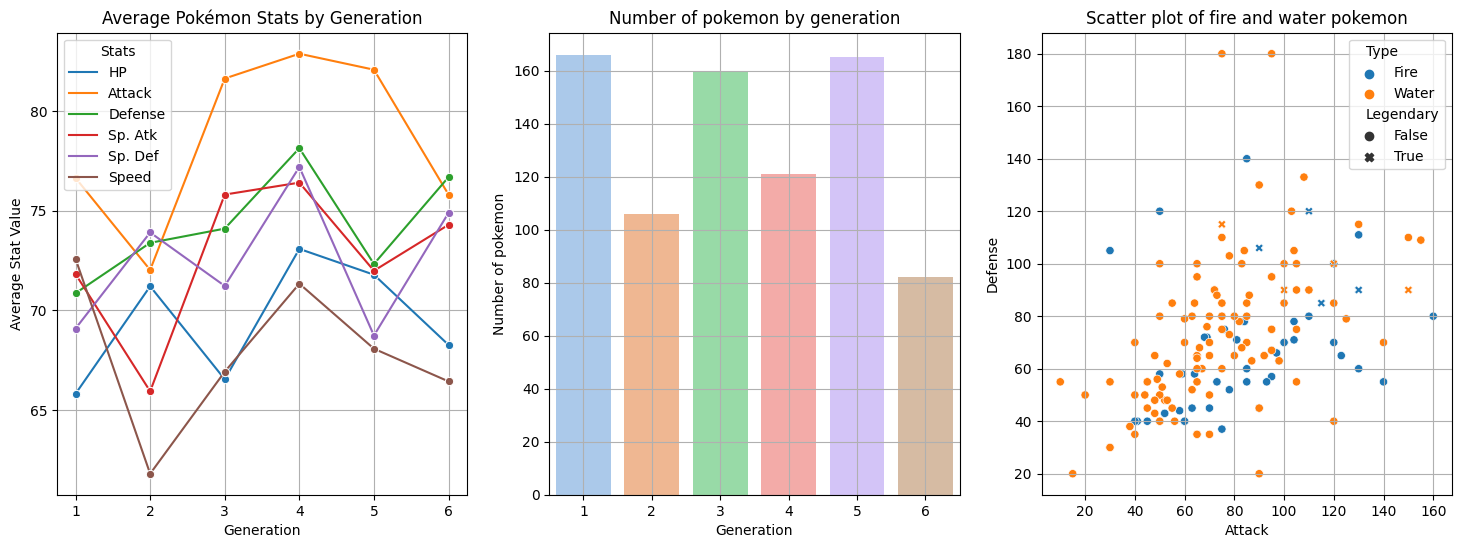

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

'''After analyzing the pokemon dataset now Sam’s mission is to analyze the stats of different Pokémon generations to discover interesting patterns and insights.
He'll need to create some visualizations to help Professor Oak understand the data better. Again he would need your help.
https://drive.google.com/file/d/1kA2P2ugD4_FlLBiiSzVME6QPMhCrSPBY/view?usp=drive_link

Here are the tasks :

Explore the Data : Start by loading the dataset and taking a quick look at 
the first few rows to see what kind of information it contains.

Prepare the Data : Set the Pokémon names as the index, and remove any 
unnecessary columns. Then, focus on the main stats like HP, Attack, Defense, etc.

Analyze Generations : Group the Pokémon by their generation and calculate 
the average values for each stat. How do these averages change from one generation to the next?

Count Pokémon : Find out how many Pokémon there are in each generation.

Compare Fire and Water Types : Create separate datasets for Fire and Water
type Pokémon. Then combine them and add a 'Type' column to distinguish between them.

Create Visualizations :
Line Plot : Show the average stats by generation.
Bar Plot : Display the number of Pokémon in each generation.
Scatter Plot : Compare Attack and Defense stats for Fire and Water Pokémon, distinguishing between Legendary and non-Legendary Pokémon.
Using Python, Seaborn, and Matplotlib, write the code to accomplish these tasks and create the visualizations. Your goal is to present your findings to Professor Oak in a clear and insightful way.

'''
df = pd.read_csv("/kaggle/input/pokemoncsv-csv/Pokemon.csv")
first_rows = df.head()
print("The first few rows is: ")
print(first_rows)
print()

df.set_index("Name", inplace = True)
df.drop(["#"], axis = 1)
print(df)

#df1 = df.iloc[:,2:].reset_index(drop = True)
#print("Reindexing...")
#print(df1)

df1 = df[["Generation","HP","Attack","Defense","Sp. Atk","Sp. Def","Speed"]]

generation_stat = df1.groupby("Generation").mean()
print("The average values for each stat is: ")
print(generation_stat)

generation_counts = df["Generation"].value_counts().sort_index()
print("The number of pokemons in each gen is: ")
print(generation_counts)

fire_df = df[df["Type 1"] == "Fire"]
fire_df["Type"] = "Fire"
water_df = df[df["Type 1"]=="Water"]
water_df["Type"] = "Water"
fire_water_df = pd.concat([fire_df,water_df])
print(fire_water_df)
print()

# PLOTS
generation_stat_long = generation_stat.reset_index().melt(id_vars="Generation", 
                                                           var_name="Stats", 
                                                           value_name="Average Value")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.lineplot(data=generation_stat_long, x="Generation", y="Average Value", hue="Stats", marker="o", ax=axes[0])
axes[0].set_title("Average Pokémon Stats by Generation")
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Average Stat Value")
axes[0].grid(True)

sns.barplot(x=generation_counts.index,y=generation_counts.values,ax=axes[1],palette="pastel")
axes[1].set_title("Number of pokemon by generation")
axes[1].set_xlabel("Generation")
axes[1].set_ylabel("Number of pokemon")
axes[1].grid(True)

sns.scatterplot(data=fire_water_df,x="Attack",y="Defense",hue="Type",style="Legendary",ax=axes[2])
axes[2].set_title("Scatter plot of fire and water pokemon")
axes[2].set_xlabel("Attack")
axes[2].set_ylabel("Defense")
axes[2].grid(True)
